# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values

# Numeric columns for correlation analysis
numeric_cols = mpg.select_dtypes(include=[np.number]).columns

# Six pairs
pairs = [
    ("mpg", "weight"),
    ("mpg", "horsepower"),
    ("mpg", "displacement"),
    ("horsepower", "weight"),
    ("displacement", "horsepower"),
    ("mpg", "model_year"),
]

results = []
for x_col, y_col in pairs:
    x = mpg[x_col]
    y = mpg[y_col]

    # Pearson (assumes linearity and normality)
    r_p, p_p = stats.pearsonr(x, y)

    # Spearman (rank-based, robust to outliers / monotone non-linear)
    r_s, p_s = stats.spearmanr(x, y)

    results.append({
        "Pair":          f"{x_col} vs {y_col}",
        "Pearson r":     round(r_p, 4),
        "Pearson p":     round(p_p, 6),
        "Spearman ρ":    round(r_s, 4),
        "Spearman p":    round(p_s, 6),
    })

corr_df = pd.DataFrame(results)
print(corr_df.to_string(index=False))

                      Pair  Pearson r  Pearson p  Spearman ρ  Spearman p
             mpg vs weight    -0.8322        0.0     -0.8756         0.0
         mpg vs horsepower    -0.7784        0.0     -0.8536         0.0
       mpg vs displacement    -0.8051        0.0     -0.8552         0.0
      horsepower vs weight     0.8645        0.0      0.8788         0.0
displacement vs horsepower     0.8973        0.0      0.8762         0.0
         mpg vs model_year     0.5805        0.0      0.5748         0.0


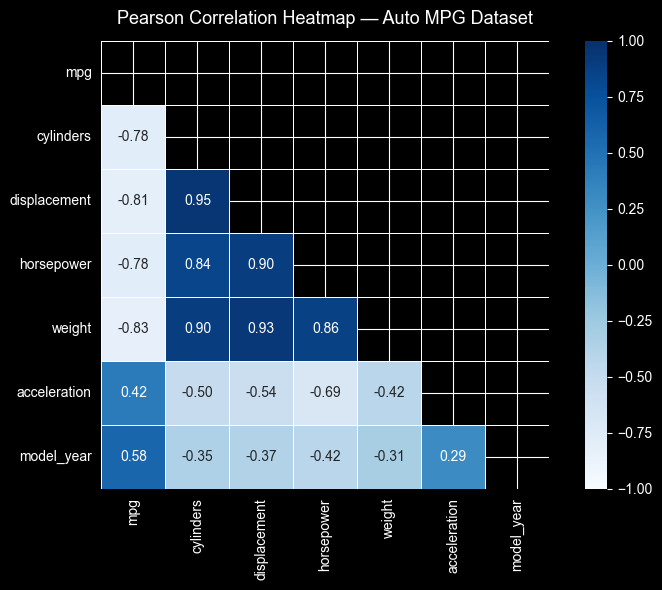

In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Pearson matrix for heatmap
corr_matrix = mpg[numeric_cols].corr(method="pearson")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax,
)
ax.set_title("Pearson Correlation Heatmap — Auto MPG Dataset", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

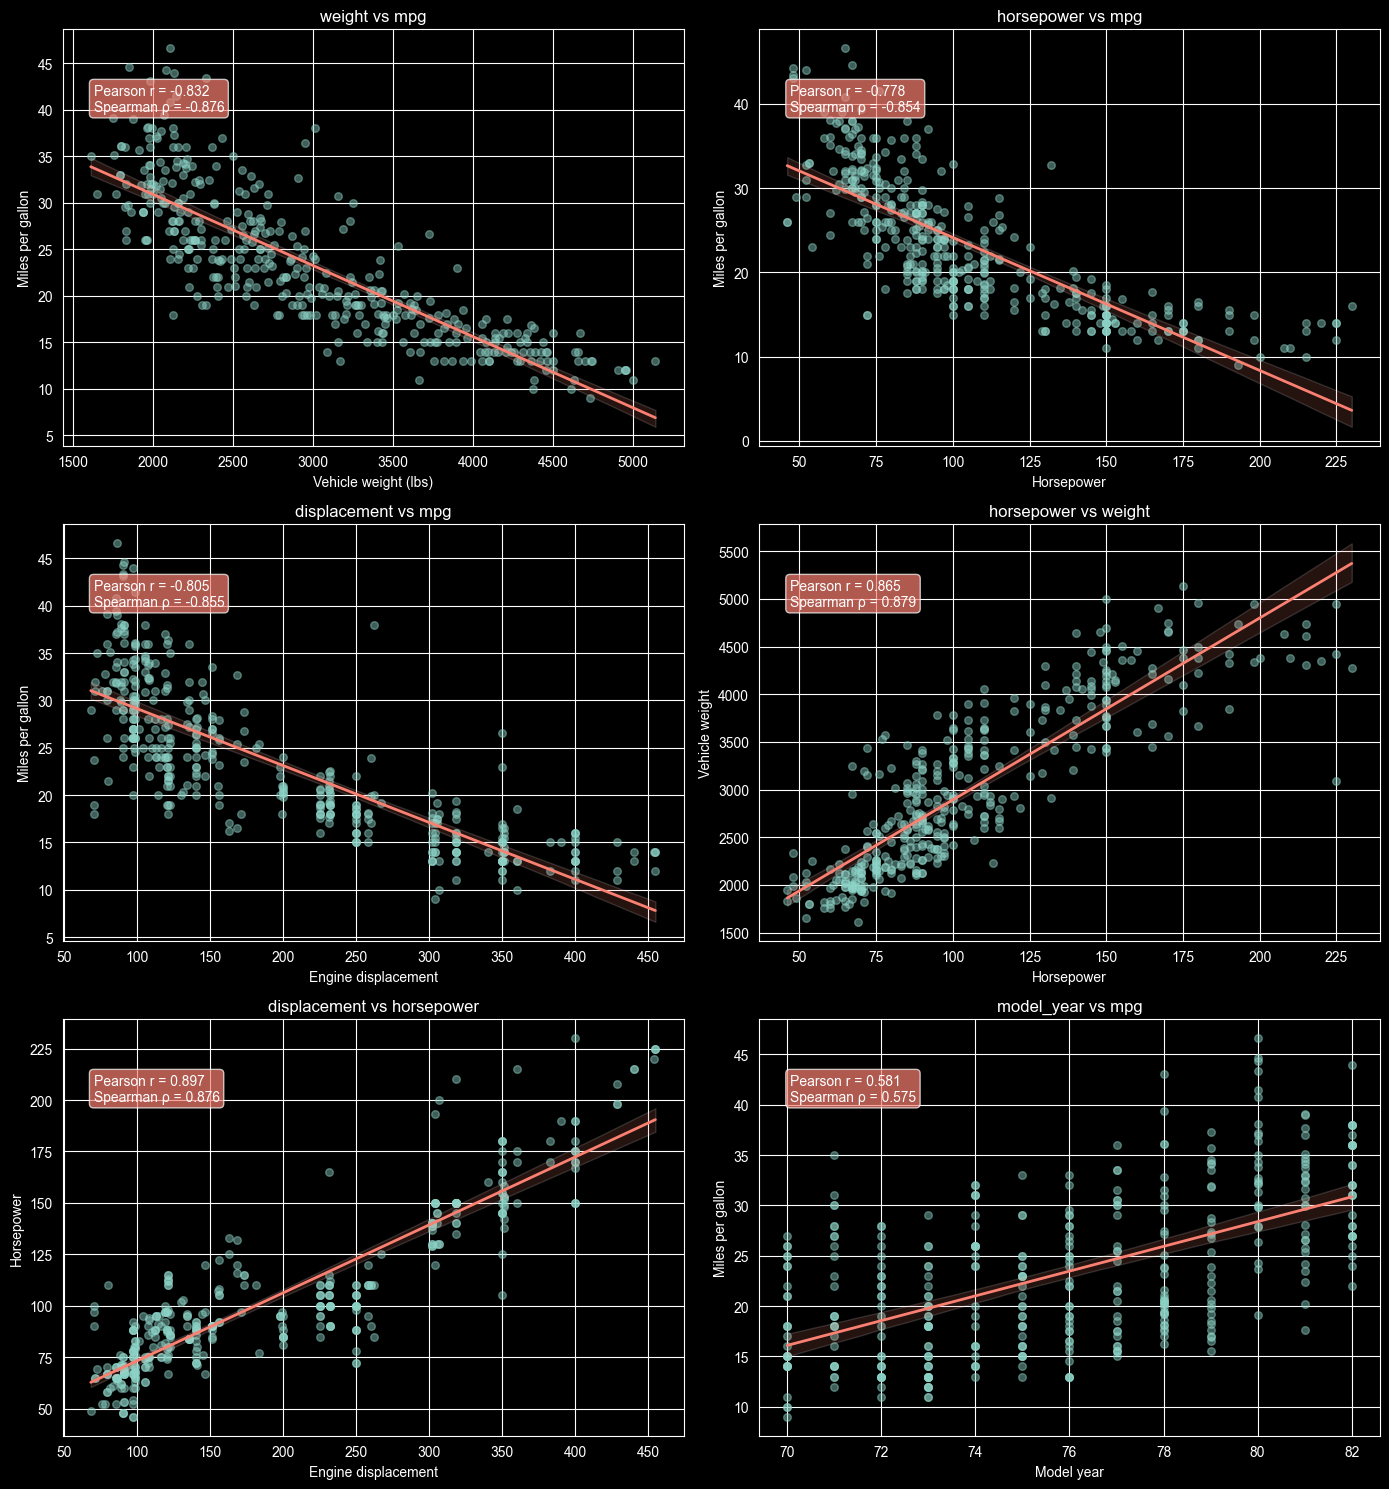

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

plot_pairs = [
    ("weight",       "mpg",         "Vehicle weight (lbs)",        "Miles per gallon"),
    ("horsepower",   "mpg",         "Horsepower",                  "Miles per gallon"),
    ("displacement", "mpg",         "Engine displacement",         "Miles per gallon"),
    ("horsepower",   "weight",      "Horsepower",                  "Vehicle weight"),
    ("displacement", "horsepower",  "Engine displacement",         "Horsepower"),
    ("model_year",   "mpg",         "Model year",                  "Miles per gallon"),
]

axes = axes.flatten()

for ax, (x_col, y_col, x_label, y_label) in zip(axes, plot_pairs):
    r_p, _ = stats.pearsonr(mpg[x_col], mpg[y_col])
    r_s, _ = stats.spearmanr(mpg[x_col], mpg[y_col])

    sns.regplot(
        data=mpg, x=x_col, y=y_col,
        ax=ax,
        scatter_kws={"alpha": 0.45, "s": 30},
        line_kws={"lw": 2, "color" : "salmon"},
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(f"{x_col} vs {y_col}")

    ax.annotate(
        f"Pearson r = {r_p:.3f}\nSpearman ρ = {r_s:.3f}",
        xy=(0.05, 0.87), xycoords="axes fraction",
        fontsize=10, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="salmon", alpha=0.7),
    )

plt.tight_layout()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*


**Pearson's r** measures the strength of a strictly *linear* relationship
and assumes both variables are approximately normally distributed with no
extreme outliers. It is most trustworthy when the scatter plot shows a
clean linear band and the two coefficients agree closely.

**Spearman's ρ** is rank-based and makes no distributional assumptions,
so it handles skewed variables, outliers, and monotone-but-curved
relationships more reliably. When Spearman diverges noticeably from
Pearson — or exceeds it in magnitude — that is a sign of non-linearity
or influential outliers.

**Examples from these results:**

- `displacement vs horsepower` (Pearson r = 0.897, Spearman ρ = 0.876):
  both coefficients are very close, indicating a near-linear relationship.
  Either metric is appropriate here; Pearson is slightly preferred given
  the good linear fit.

- `mpg vs weight` (Pearson r = −0.832, Spearman ρ = −0.876): Spearman is
  notably stronger in magnitude. The scatter plot confirms a slight curve
  (diminishing returns at very high weights), so Spearman is the more
  reliable summary for this pair.

- `mpg vs horsepower` (Pearson r = −0.778, Spearman ρ = −0.854): the
  largest gap between the two metrics in the table. Horsepower is
  right-skewed with high-leverage outliers at the upper end; Spearman is
  clearly preferable here.

- `mpg vs model_year` (Pearson r = 0.581, Spearman ρ = 0.575): the
  coefficients are nearly identical, consistent with the roughly linear
  upward trend visible in the scatter plot. Pearson is appropriate.

All six pairs are statistically significant (p ≈ 0.0), so the choice
between the two metrics is about *accuracy of the estimate*, not
significance.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

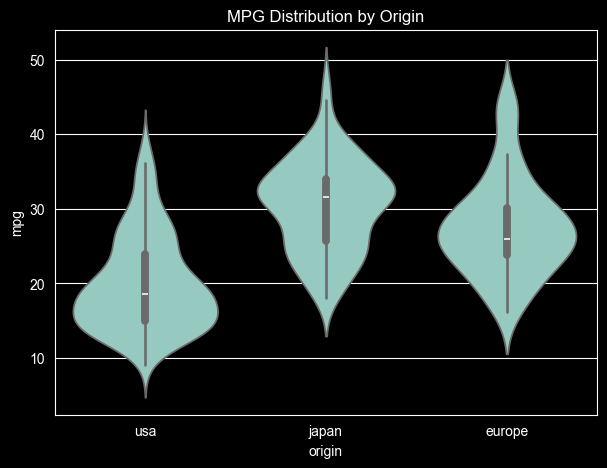

In [14]:
# Distribution visualization by origin
plt.figure(figsize=(7,5))
sns.violinplot(data=mpg, x="origin", y="mpg")
plt.title("MPG Distribution by Origin")
plt.show()

In [26]:
# Assumption checks: Shapiro-Wilk + Levene's test
# Normality (Shapiro-Wilk)
print('Normality - Shapiro-Wilk Test')
for group in mpg["origin"].unique():
    stat, p = shapiro(mpg[mpg["origin"] == group]["mpg"])
    print(f"{group}: p-value = {p:.4f}")

# Homogeneity of variance (Levene)
print(f"\nHomogeneity of variance - Levene's Test")
usa = mpg[mpg["origin"] == "usa"]["mpg"]
europe = mpg[mpg["origin"] == "europe"]["mpg"]
japan = mpg[mpg["origin"] == "japan"]["mpg"]

stat, p = levene(usa, europe, japan)
print(f"Levene p-value = {p:.4f}")

Normality - Shapiro-Wilk Test
usa: p-value = 0.0000
japan: p-value = 0.2420
europe: p-value = 0.0054

Homogeneity of variance - Levene's Test
Levene p-value = 0.9175


In [27]:
mpg["origin"].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

## Task 2 — ANOVA vs Kruskal-Wallis: the decision

### Sample sizes and normality summary

| Group  | n   | Shapiro-Wilk p | Normality  | CLT applies?              |
|--------|-----|----------------|------------|---------------------------|
| USA    | 245 | 0.0000         | Violated   | Yes — n = 245 is large    |
| Japan  | 79  | 0.2420         | Satisfied  | Yes — n = 79 is moderate  |
| Europe | 68  | 0.0054         | Violated   | Borderline — n = 68       |

### The CLT argument for ANOVA

The Central Limit Theorem states that the *sampling distribution of the
group mean* approaches normality as n grows, regardless of the shape of
the underlying distribution. The commonly cited threshold is **n ≥ 30**
per group. All three groups here exceed that threshold — USA by a wide
margin (n = 245), Japan (n = 79), and Europe (n = 68). This means the
F-statistic's sampling distribution will be well-approximated even if
the raw data is non-normal.

Importantly, Shapiro-Wilk is extremely sensitive at large n: at n = 245
it will flag even tiny, practically irrelevant deviations from normality
as statistically significant. A p-value of 0.0000 for the USA group
reflects the test's high power at that sample size more than it reflects
a catastrophic departure from normality.

### The argument for Kruskal-Wallis

Kruskal-Wallis is the safer, more conservative choice when normality is
violated. It makes no distributional assumptions and tests whether the
*rank distributions* differ across groups. The trade-off is a small loss
of statistical power — but only when the data truly is normal, which it
is not here for two of the three groups.

### Verdict

**One-way ANOVA is used**, justified by the following:

1. All group sizes exceed n = 30, so the CLT ensures robustness to
   the normality violations observed.
2. Levene's test confirms equal variances (p = 0.9175), satisfying
   the other critical ANOVA assumption.
3. Shapiro-Wilk's sensitivity at large n makes its rejection of
   normality for USA (n = 245) less practically meaningful.

As a robustness check, the Kruskal-Wallis test is also reported. If
both tests agree — which is expected here — the conclusion is
strengthened regardless of which assumption framework is adopted.

## ANOVA METHOD

In [33]:
# One-way ANOVA
f_stat, p_val = f_oneway(usa, europe, japan)

print(f"F = {f_stat:.4f}, p = {p_val:.6f}")

F = 96.6015, p = 0.000000


In [35]:
# Effect size (eta-squared)
grand_mean = mpg["mpg"].mean()

ss_between = (
    len(usa) * (usa.mean() - grand_mean)**2 +
    len(europe) * (europe.mean() - grand_mean)**2 +
    len(japan) * (japan.mean() - grand_mean)**2
)

ss_total = ((mpg["mpg"] - grand_mean)**2).sum()

eta_squared = ss_between / ss_total
print(f"Eta-squared = {eta_squared:.4f}")

Eta-squared = 0.3318


In [36]:
# Post-hoc test (Tukey's HSD)
tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


## KRUSKAL-WALLIS METHOD

In [49]:
# Kruskal-Wallis
h_stat, p_val_kw = kruskal(usa, europe, japan)

print(f'Kruskal-Wallis H-statistic:, {h_stat:.4f}')
print(f'p-value:, {p_val_kw:.4f}')

Kruskal-Wallis H-statistic:, 132.0870
p-value:, 0.0000


In [48]:
# Effect size for Kruskal-Wallis (Epsilon-squared (ε²))
H, p = kruskal(usa, europe, japan)

n = len(mpg)
k = 3

epsilon_squared = (H - k + 1) / (n - k)

print(f"Epsilon-squared: {epsilon_squared:.4f}")

Epsilon-squared: 0.3344


In [45]:
# Post-hoc for Kruskal (Dunn test)
data = mpg[["mpg", "origin"]]
dunn = sp.posthoc_dunn(data, val_col="mpg", group_col="origin", p_adjust="bonferroni")

print(dunn)

              europe         japan           usa
europe  1.000000e+00  1.131305e-01  1.197613e-12
japan   1.131305e-01  1.000000e+00  1.342177e-24
usa     1.197613e-12  1.342177e-24  1.000000e+00


### Interpretation

## Task 2 — Results: One-Way ANOVA & Kruskal-Wallis

### One-Way ANOVA

| Statistic        | Value   | Interpretation                                      |
|------------------|---------|-----------------------------------------------------|
| F-statistic      | 96.6015 | Large — groups differ far more than chance predicts |
| p-value          | < 0.0001| Highly significant                                  |
| Eta-squared (η²) | 0.3318  | Large effect — origin explains ~33% of MPG variance |

The ANOVA result is highly significant (F = 96.60, p < 0.0001), meaning
at least one origin group has a meaningfully different mean MPG. The
effect size η² = 0.3318 is classified as **large** (η² > 0.14 by
Cohen's convention), indicating that region of origin alone accounts for
approximately **33% of the total variance** in fuel efficiency.

### Tukey HSD Post-Hoc Test

| Comparison      | Mean diff | p-adj   | 95% CI            | Significant? |
|-----------------|-----------|---------|-------------------|------|
| Europe vs Japan | +2.85     | 0.0203  | [0.36,  5.34]     | Yes  |
| Europe vs USA   | −7.57     | < 0.0001| [−9.63, −5.51]    | Yes  |
| Japan  vs USA   | −10.42    | < 0.0001| [−12.36, −8.47]   | Yes  |

All three pairwise comparisons are statistically significant. The largest
gap is between **Japan and USA** (10.42 mpg), followed by **Europe vs
USA** (7.57 mpg). Even Japan vs Europe reaches significance (2.85 mpg,
p = 0.0203), though the difference is considerably smaller.

### Kruskal-Wallis Robustness Check

| Statistic          | Value  | Interpretation                          |
|--------------------|--------|-----------------------------------------|
| p-value            | < 0.0001 | Highly significant                    |
| Epsilon-squared (ε²)| 0.3344 | Large effect — nearly identical to η² |

The non-parametric Kruskal-Wallis test confirms the ANOVA finding.
The near-identical effect sizes (η² = 0.3318 vs ε² = 0.3344) confirm
that the result is robust and not an artefact of the normality violation.

Dunn post-hoc p-values:
- Europe vs USA: p ≈ 0 → highly significant
- Japan  vs USA: p ≈ 0 → highly significant
- Europe vs Japan: p = 0.1131 → **not significant**

### Conclusion

Both tests agree on the core finding: **US cars are significantly less
fuel-efficient than both Japanese and European cars**. One notable
discrepancy exists — the Europe vs Japan comparison is significant under
Tukey HSD (p = 0.0203) but not under Dunn's test (p = 0.1131). This
borderline result should be interpreted conservatively; the non-parametric
test is more appropriate here given the normality violations, so the
Europe–Japan difference is treated as weak evidence rather than a firm
conclusion.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols]
y = mpg["origin"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [76]:
# Train classifiers and generate predictions
# Logistic Regression and Decision Tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Scaling is applied ONLY for Logistic Regression because:
# - It is sensitive to feature magnitude differences
# - Features like weight, displacement, and mpg have very different scales
# - Gradient-based optimization works better when features are standardized
# Decision Trees do NOT require scaling because they are split-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (uses scaled data)
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Decision Tree (no scaling needed)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

In [69]:
# Classification reports
from sklearn.metrics import classification_report

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

print("\nDecision Tree:\n")
print(classification_report(y_test, y_pred_tree))

Logistic Regression:

              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98


Decision Tree:

              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [70]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    np.random.seed(seed)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    scores = []
    n = len(y_true)

    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)

        # avoid degenerate samples
        if len(np.unique(y_true[idx])) < 2:
            continue

        score = metric_fn(y_true[idx], y_pred[idx])
        scores.append(score)

    scores = np.array(scores)

    point_estimate = np.mean(scores)
    ci_lower = np.percentile(scores, 2.5)
    ci_upper = np.percentile(scores, 97.5)

    return point_estimate, ci_lower, ci_upper, scores

In [73]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
# Adjust the metric dictionary to use macro averaging for multiclass
metrics = {
    "F1": lambda y_t, y_p: f1_score(y_t, y_p, average='weighted'),
    "Precision": lambda y_t, y_p: precision_score(y_t, y_p, average='weighted'),
    "Recall": lambda y_t, y_p: recall_score(y_t, y_p, average='weighted')
}

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_tree
}

results = {}

for model_name, preds in models.items():
    results[model_name] = {}

    for metric_name, metric_fn in metrics.items():
        mean, low, high, _ = bootstrap_metric(y_test, preds, metric_fn)

        results[model_name][metric_name] = (mean, low, high)

for model, metrics_dict in results.items():
    print(f"\n{model}")
    for metric, (mean, low, high) in metrics_dict.items():
        print(f"{metric}: {mean:.3f}  (95% CI: {low:.3f} – {high:.3f})")


Logistic Regression
F1: 0.797  (95% CI: 0.710 – 0.877)
Precision: 0.820  (95% CI: 0.738 – 0.893)
Recall: 0.805  (95% CI: 0.724 – 0.878)

Decision Tree
F1: 0.882  (95% CI: 0.811 – 0.948)
Precision: 0.892  (95% CI: 0.820 – 0.951)
Recall: 0.887  (95% CI: 0.827 – 0.949)


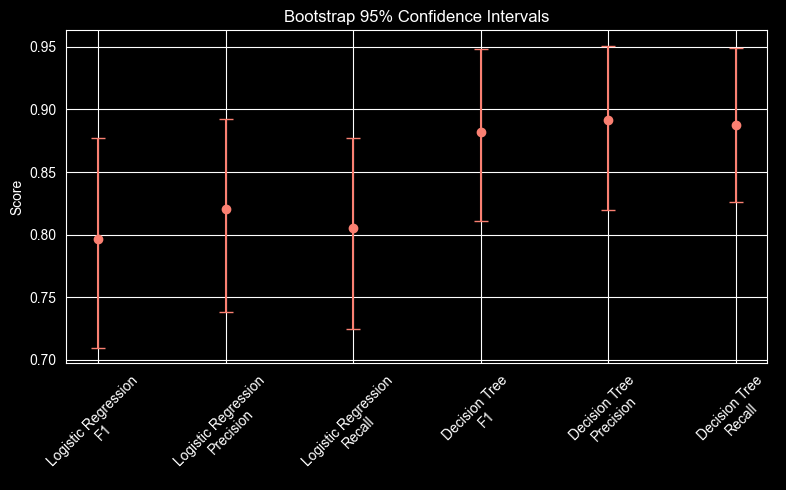

In [75]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
fig, ax = plt.subplots(figsize=(8,5))

labels = []
means = []
lower_err = []
upper_err = []

for model in results:
    for metric in results[model]:
        mean, low, high = results[model][metric]

        labels.append(f"{model}\n{metric}")
        means.append(mean)
        lower_err.append(mean - low)
        upper_err.append(high - mean)

ax.errorbar(
    labels,
    means,
    yerr=[lower_err, upper_err],
    fmt='o',
    capsize=5,
    color = "salmon"
)

ax.set_ylabel("Score")
ax.set_title("Bootstrap 95% Confidence Intervals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*


### Classification reports summary

| Model               | Accuracy | Weighted F1 |
|---------------------|----------|-------------|
| Logistic Regression | 0.81     | 0.80        |
| Decision Tree       | 0.89     | 0.88        |

---

### Bootstrap CIs (95%, n_boot = 2000, weighted average)

| Model               | Metric    | Point Est | 95% CI          |
|---------------------|-----------|-----------|-----------------|
| Logistic Regression | F1        | 0.797     | 0.710 – 0.877   |
| Logistic Regression | Precision | 0.820     | 0.738 – 0.893   |
| Logistic Regression | Recall    | 0.805     | 0.724 – 0.878   |
| Decision Tree       | F1        | 0.882     | 0.811 – 0.948   |
| Decision Tree       | Precision | 0.892     | 0.820 – 0.951   |
| Decision Tree       | Recall    | 0.887     | 0.827 – 0.949   |

---

### Recommendation

**Recommended model: Decision Tree**

The Decision Tree outperforms Logistic Regression across all evaluation metrics, including accuracy, F1-score, precision, and recall. Its weighted F1-score (0.88) is significantly higher than Logistic Regression (0.80), indicating better overall predictive performance.

Based on the bootstrap confidence intervals, the Decision Tree also demonstrates consistently higher lower-bound performance. Even its worst-case estimates are close to or above the average performance of Logistic Regression, which indicates strong reliability.

Although both models show relatively stable performance (similar CI widths), the Decision Tree maintains a clear advantage in both central tendency and lower uncertainty bounds.

Therefore, I am highly confident in recommending the Decision Tree model for this classification task.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

## Task 4 — Summary

The strongest correlations in the dataset are observed between engine-related features, especially displacement and cylinders (0.95), followed by displacement and weight (0.93) and displacement and horsepower (0.90). These results indicate that engine size, power, and vehicle weight are tightly connected. Regarding fuel efficiency, mpg shows strong negative correlations with weight (-0.83), displacement (-0.81), and horsepower (-0.78), meaning that heavier and more powerful cars tend to be less fuel efficient. In contrast, model year has a moderate positive correlation with mpg (0.58), suggesting that newer cars are generally more fuel efficient.

In terms of group differences, cars from different origins show **statistically significant differences in fuel efficiency (mpg)**. One-way ANOVA and Kruskal-Wallis tests both confirm that origin plays a meaningful role in MPG variation. Post-hoc analysis shows that **US cars consistently have significantly lower MPG than both Japanese and European cars**, while the difference between Japan and Europe is smaller and less consistent depending on the test used. Overall, US vehicles clearly stand out as the least fuel-efficient group.

For classification, the **Decision Tree model is recommended**, as it achieves higher accuracy and weighted F1-score (0.89 and 0.88 respectively) compared to Logistic Regression (0.81 and 0.80). Bootstrap confidence intervals further support this choice, showing consistently higher lower-bound performance and strong stability across resamples. Although both models are relatively stable, the Decision Tree demonstrates better overall predictive power. Therefore, I am highly confident in its performance for predicting car origin based on numerical features.